In [45]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import contextily as ctx
import numpy as np
from pyproj import Transformer
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from matplotlib.ticker import FormatStrFormatter
import warnings
import json
import pandas as pd
warnings.filterwarnings('ignore')

# EU-Forest, a high-resolution tree occurrence dataset for Europe (Published in 2017)
[Paper link: ](https://www.nature.com/articles/sdata2016123) \
[Data access for each specie: ](https://data.jrc.ec.europa.eu/dataset?pw=2&collection=JRC-FOREST&q=forest&sort=title-asc) \
[Sample specie data page: ](https://data.jrc.ec.europa.eu/dataset/24362f17-7935-4a27-8cac-7a6e5b37bae8) \
[Some official documents not used: ](https://forest.jrc.ec.europa.eu/en/european-atlas/atlas-download-page/)

## Content
1. [Load Sample TIF](###Load-Sample-TIF)
2. [Plot Histogram](###Plot-Histogram)
3. [Visualize the Sample](###Visualize-the-Sample)
4. [Visualize the Selected Area](###Visualize-the-Selected-Area)
5. [Species Offered](###Species-Offered)


### Load Sample TIF

In [2]:
# Read the Picea abies raster file
with rasterio.open('data/species_3/Picea-abies_rpp.tif') as src:
    profile = src.profile
    for key, value in profile.items():
        print(f"{key}: {value}")
    print('resolution: ', src.res)
    print('bounds: ', src.bounds)
    print('bands: ', src.count)
    
    nodata = src.nodata
    band = src.read(1)
    bounds = src.bounds
    transform = src.transform
    height, width = src.height,src.width
    crs = src.crs

driver: GTiff
dtype: float32
nodata: -3.4028234663852886e+38
width: 4900
height: 4300
count: 1
crs: EPSG:3035
transform: | 1000.00, 0.00, 2500000.00|
| 0.00,-1000.00, 5600000.00|
| 0.00, 0.00, 1.00|
blockxsize: 4900
blockysize: 1
tiled: False
compress: lzw
interleave: band
resolution:  (1000.0, 1000.0)
bounds:  BoundingBox(left=2500000.0, bottom=1300000.0, right=7400000.0, top=5600000.0)
bands:  1


### Plot Histogram

values, valid_filtered_values counts:  21070000 1158176
min, max value:  0.100000314 0.998394


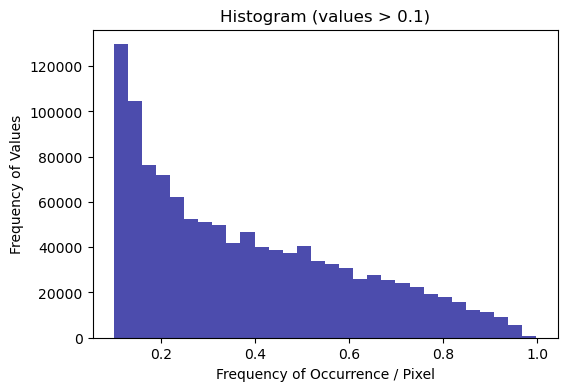

values, valid_filtered_values counts:  21070000 5164125
min, max value:  1e-45 0.998394


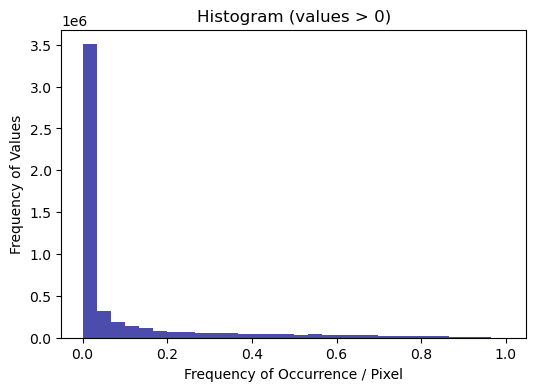

In [5]:
def histogram_plot(band, mask):
    # Mask the nodata, -1, and 0 values in the band
    filtered_band = np.ma.masked_where((band <= mask), band)
    # Extract only the valid (non-masked) values for the most frequent value calculation
    valid_filtered_values = filtered_band.compressed()
    print('values, valid_filtered_values counts: ', len(band.flatten()), len(valid_filtered_values))
    print('min, max value: ', valid_filtered_values.min(), valid_filtered_values.max())

    plt.figure(figsize=(6, 4))
    # Use a logarithmic scale for the y-axis to reduce the height of some columns
    plt.hist(valid_filtered_values, bins=30, color='darkblue', alpha=0.7)
    plt.title('Histogram (values > ' + str(mask) + ')')
    plt.xlabel('Frequency of Occurrence / Pixel')
    plt.ylabel('Frequency of Values')
    plt.show()

histogram_plot(band, 0.1)
histogram_plot(band, 0)

### Visualize the Sample

In [6]:
def reproject_to_wgs84(band):
    """
    for visualization
    """
    dst_crs = "EPSG:4326"
    src_crs = profile['crs']
    width, height = profile['width'], profile['height']
    left, right, bottom, top = bounds.left, bounds.right, bounds.bottom, bounds.top
    src_transform = profile['transform']

    transform,new_width, new_height= calculate_default_transform(
        src_crs, dst_crs, width, height,
        left=left, bottom=bottom, right=right, top=top)
    
    dst = np.zeros((new_height, new_width), dtype=np.float32)

    reproject(
        source=band,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )

    return dst, transform

In [33]:
def filter_data(band):
    pass

def visualize_data_transformed(band, title, clip_left = -15, clip_right = 36, clip_bottom = 34, clip_top = 70, alpha=0.9, zoom=6):
    reprojected_band, dst_transform = reproject_to_wgs84(band)
    filtered = filter_data(reprojected_band)

    left, top = dst_transform.c, dst_transform.f
    right = left + dst_transform.a * filtered.shape[1]
    bottom = top + dst_transform.e * filtered.shape[0]

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    im = ax.imshow(filtered, cmap='viridis', alpha=alpha,
              extent=[left, right, bottom, top],
              transform=ccrs.PlateCarree(),
              zorder=10,
              aspect='auto')
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.7)
    cbar.set_label("Frequency")

    # Add OSM basemap

    # Grid and formatting
    gl = ax.gridlines(draw_labels=True, alpha=0.4)
    gl.top_labels, gl.right_labels = False, False
    ax.set_title(title)

    ax.set_xlim(clip_left, clip_right)
    ax.set_ylim(clip_bottom, clip_top)

    ctx.add_basemap(ax, crs=ccrs.PlateCarree(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=zoom)

    # ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    # ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.tight_layout()
    plt.show()

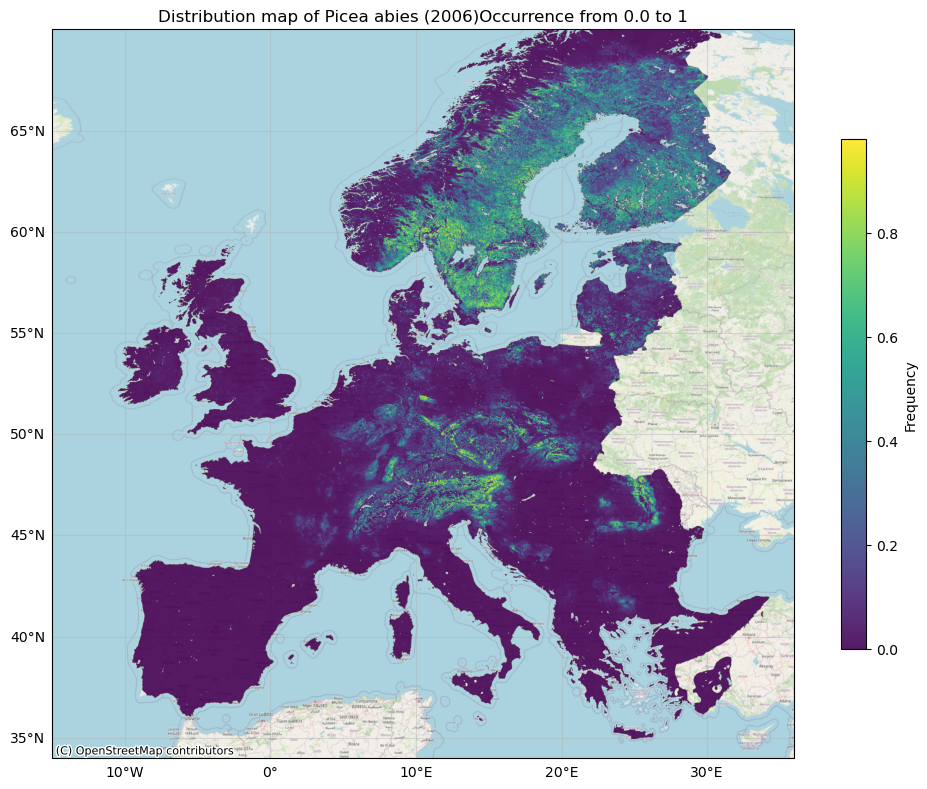

In [18]:
mask = 0.0
title = 'Distribution map of Picea abies (2006)' + 'Occurrence from ' + str(mask) + ' to 1'
def filter_data(band):
    return np.ma.masked_where((band <= mask), band)
visualize_data_transformed(band, title)

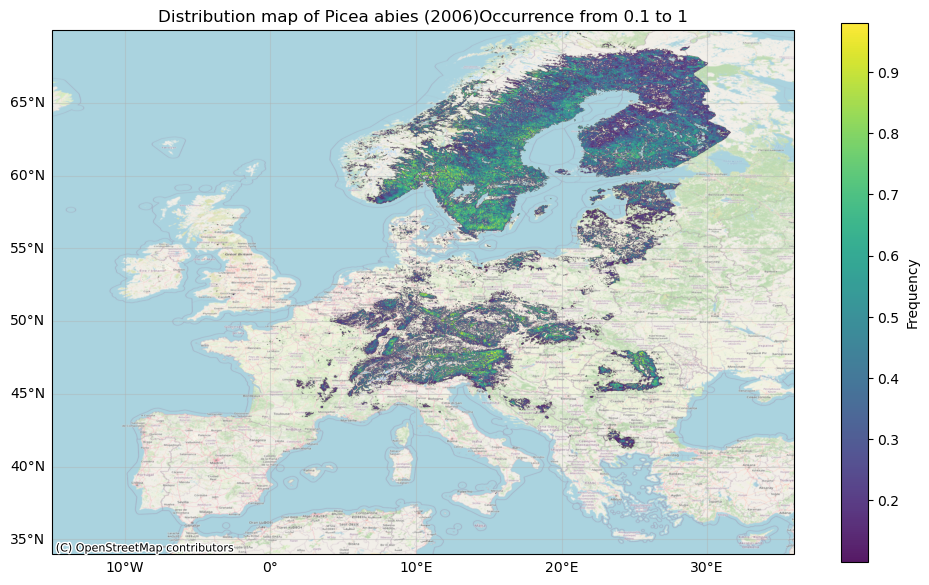

In [11]:
mask = 0.1
title = 'Distribution map of Picea abies (2006)' + 'Occurrence from ' + str(mask) + ' to 1'
def filter_data(band):
    return np.ma.masked_where((band <= mask), band)
visualize_data_transformed(band, title)

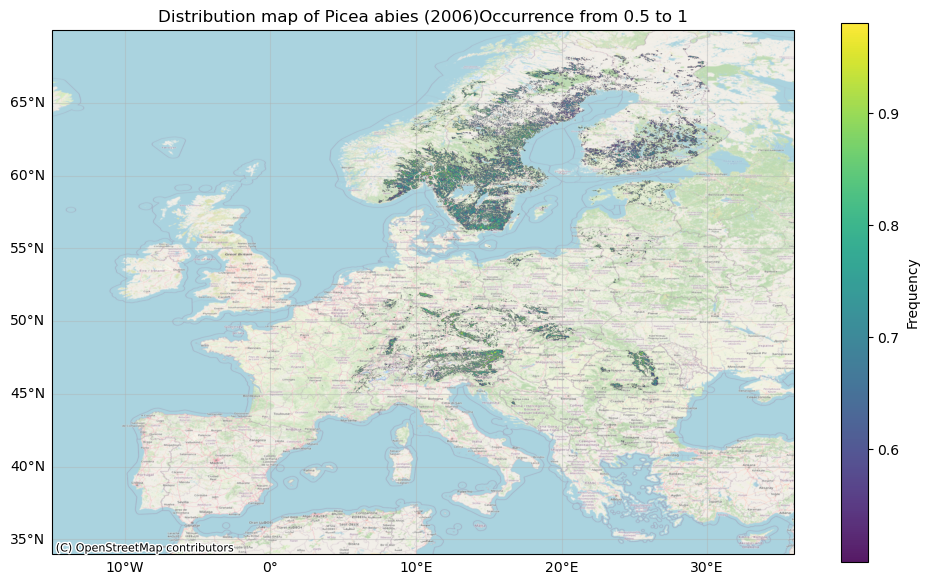

In [ ]:
mask = 0.5
title = 'Distribution map of Picea abies (2006) ' + 'Occurrence from ' + str(mask) + ' to 1'
def filter_data(band):
    return np.ma.masked_where((band <= mask), band)
visualize_data_transformed(band, title)

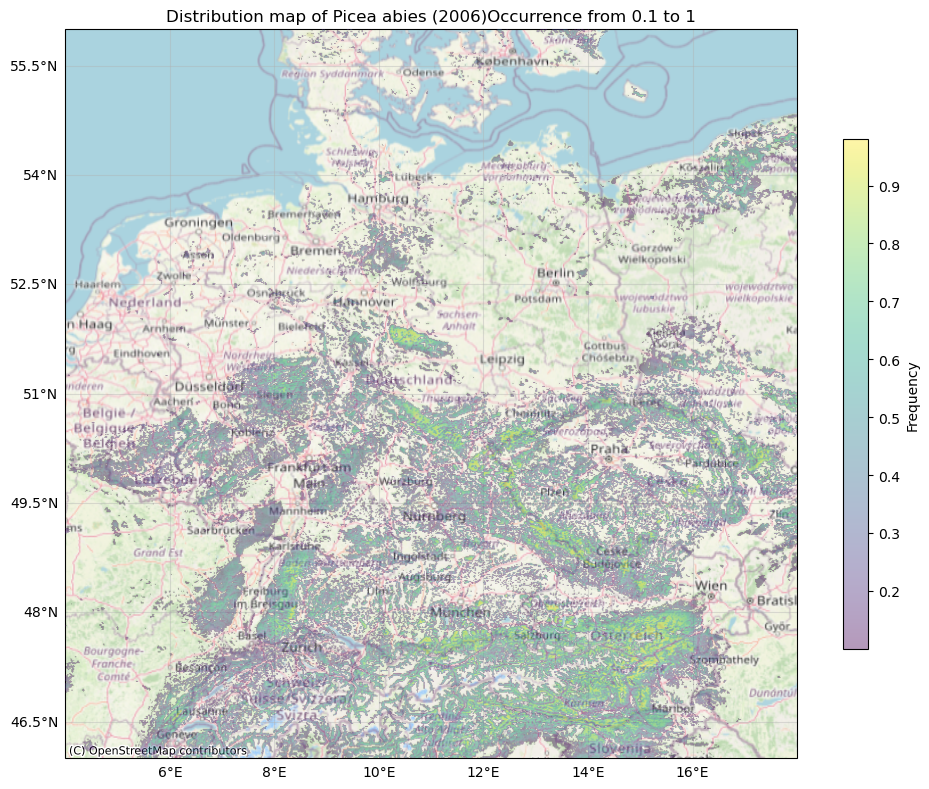

In [26]:
mask = 0.1
title = 'Distribution map of Picea abies (2006) ' + 'Occurrence from ' + str(mask) + ' to 1'
clip = [4, 18, 46, 56]
def filter_data(band):
    return np.ma.masked_where((band <= mask), band)
visualize_data_transformed(band, title, *clip, 0.4)

### Visualize in the Selected Area

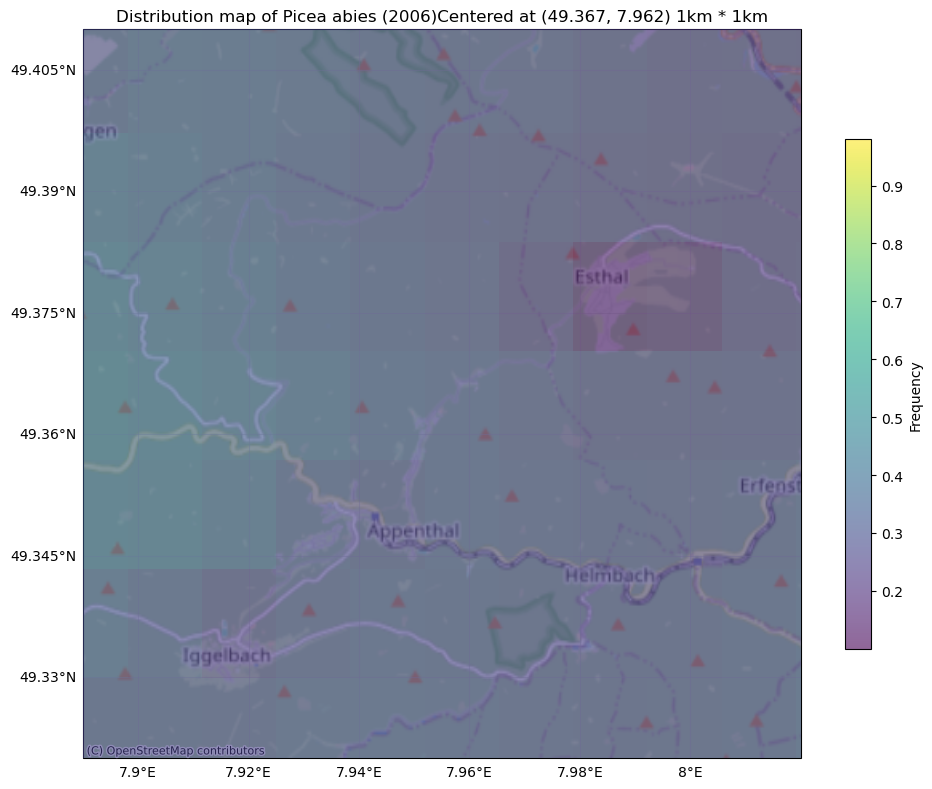

In [ ]:
# 7.894041354606359, 49.32145771789836, 8.029859431055153, 49.41263004661555
mask = 0.1
title = 'Distribution map of Picea abies (2006) ' + 'Centered at (49.367, 7.962) 1km * 1km'
clip = [7.89, 8.02, 49.32, 49.41]
def filter_data(band):
    return np.ma.masked_where((band <= mask), band)
visualize_data_transformed(band, title, *clip, 0.6, 12)

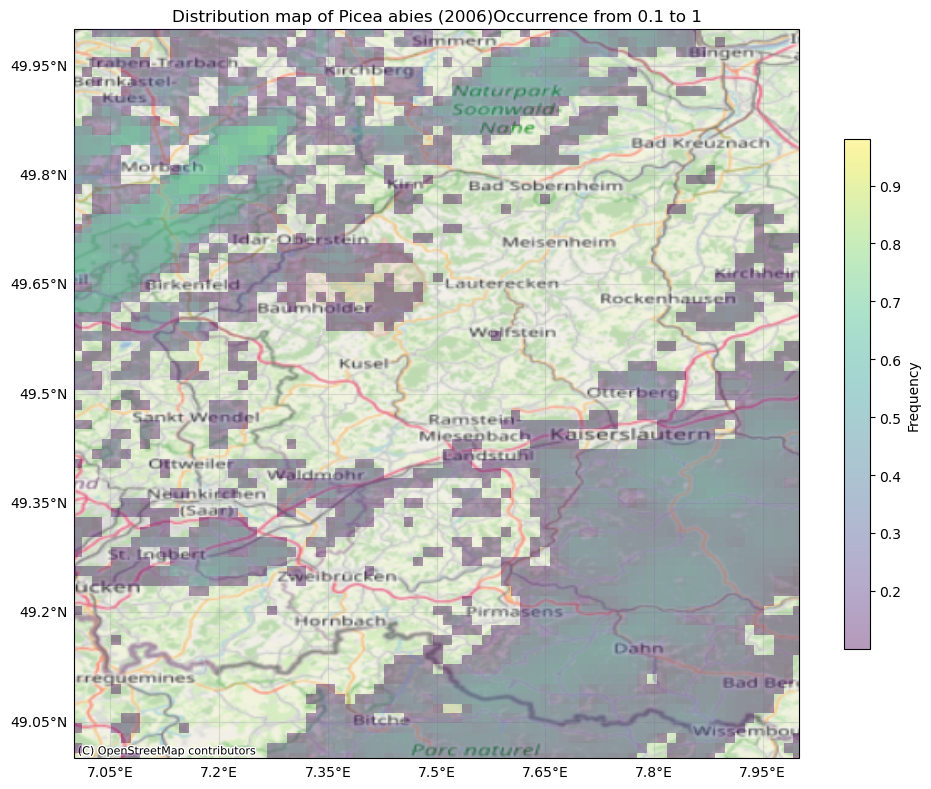

In [ ]:
mask = 0.1
title = 'Distribution map of Picea abies (2006) ' + 'Occurrence from ' + str(mask) + ' to 1'
clip = [7, 8, 49, 50]
def filter_data(band):
    return np.ma.masked_where((band <= mask), band)
visualize_data_transformed(band, title, *clip, 0.4, 9)

### Species Offered

In [48]:
# Read the JSON file back into a DataFrame
species_df = pd.read_json('data/species_3/species_name_all.json', encoding='utf-8')
species_df

,Scientific Name,Common Name,Chinese Name
0,Abies alba,Silver fir,冷杉
1,Abies spp.,Circum-Mediterranean firs,地中海冷杉
2,Acer campestre,Field maple,田野枫
3,Acer platanoides,Norway maple,挪威枫
4,Acer pseudoplatanus,Sycamore maple,欧洲枫
...,...,...,...
71,Sorbus torminalis,Wild service tree,野楸
72,Tamarix spp.,Tamarisks,柽柳
73,Taxus baccata,European yew,欧洲红豆杉
74,Tilia spp.,Limes,椴树属


In [54]:
# Read the JSON file back into a list
with open('data/species_3/species_tif_list.json', 'r', encoding='utf-8') as f:
    species_list = json.load(f)
species_list

['Abies alba',
 'Abies spp.',
 'Acer campestre',
 'Acer pseudoplatanus',
 'Alnus glutinosa',
 'Alnus incana',
 'Betula spp.',
 'Carpinus betulus',
 'Castanea sativa',
 'Corylus avellana',
 'Fagus sylvatica',
 'Fraxinus excelsior',
 'Fraxinus ornus',
 'Larix decidua',
 'Picea abies',
 'Picea sitchensis',
 'Pinus cembra',
 'Pinus contorta',
 'Pinus halepensis',
 'Pinus mugo',
 'Pinus nigra',
 'Pinus pinaster',
 'Pinus pinea',
 'Pinus sylvestris',
 'Populus nigra',
 'Populus tremula',
 'Prunus avium',
 'Pseudotsuga menziesii',
 'Quercus cerris',
 'Quercus faginea',
 'Quercus frainetto',
 'Quercus ilex',
 'Quercus petraea',
 'Quercus pubescens',
 'Quercus pyrenaica',
 'Quercus robur',
 'Quercus suber',
 'Robinia pseudoacacia',
 'Salix caprea',
 'Sorbus aucuparia',
 'Tilia spp.']

In [56]:
# Filter the species_df to only include rows where the 'Scientific Name' is in species_list
filtered_species_df = species_df[species_df['Scientific Name'].isin(species_list)]
print(len(filtered_species_df))
filtered_species_df.T

36


,0,1,2,4,8,9,11,12,14,19,...,56,57,58,60,61,63,64,66,69,74
Scientific Name,Abies alba,Abies spp.,Acer campestre,Acer pseudoplatanus,Alnus glutinosa,Alnus incana,Betula spp.,Carpinus betulus,Castanea sativa,Corylus avellana,...,Quercus cerris,Quercus frainetto,Quercus ilex,Quercus pubescens,Quercus pyrenaica,Quercus suber,Robinia pseudoacacia,Salix caprea,Sorbus aucuparia,Tilia spp.
Common Name,Silver fir,Circum-Mediterranean firs,Field maple,Sycamore maple,Common alder,Grey alder,Birches,Common hornbeam,Sweet chestnut,Common hazel,...,Turkey oak,Hungarian oak,Holm oak,Downy oak,Pyrenean oak,Cork oak,Black locust,Goat willow,Rowan,Limes
Chinese Name,冷杉,地中海冷杉,田野枫,欧洲枫,欧洲桤木,灰桤木,桦木属,欧洲鹅耳枥,欧洲栗,榛子,...,土耳其橡树,匈牙利橡树,冬青橡树,绒毛橡树,比利牛斯橡树,软木橡树,刺槐,山柳,花楸,椴树属
